In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

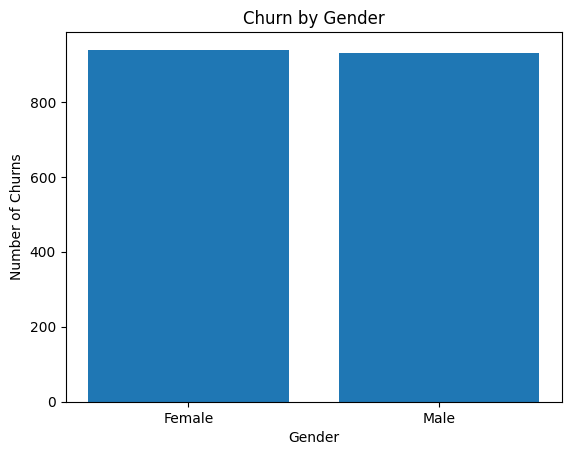

In [ ]:
churn_counts = df.groupby('gender')['Churn'].sum()
plt.bar(churn_counts.index, churn_counts.values)
plt.xlabel('Gender')
plt.ylabel('Number of Churns')
plt.title('Churn by Gender')
plt.show()

This graph infer that gender is not a significant factor in churn.

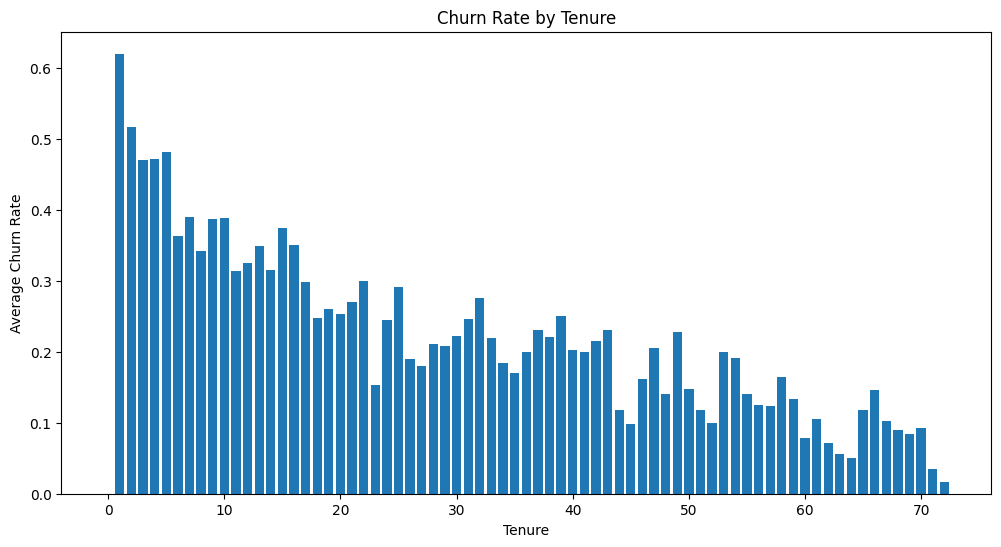

In [ ]:
churn_rate_by_tenure = df.groupby('tenure')['Churn'].mean()

plt.figure(figsize=(12, 6))
plt.bar(churn_rate_by_tenure.index, churn_rate_by_tenure.values)
plt.xlabel('Tenure')
plt.ylabel('Average Churn Rate')
plt.title('Churn Rate by Tenure')
plt.show()


The bar plot demonstrates that the churn rate decreases as customer tenure increases

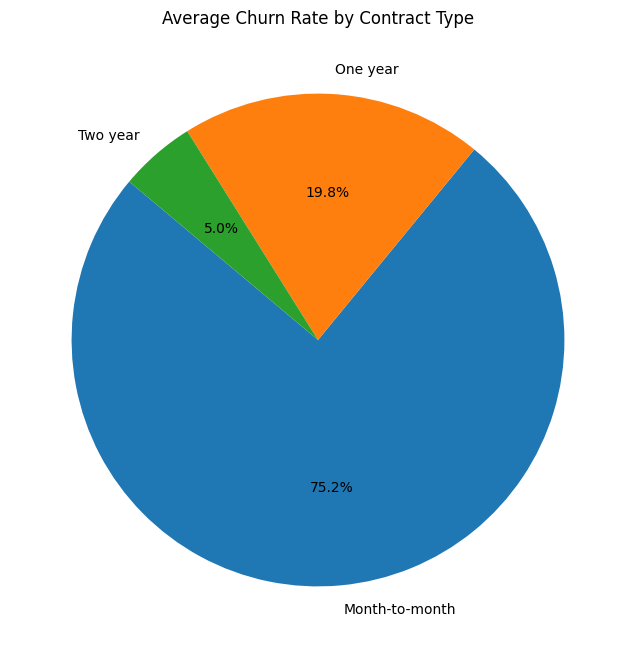

In [ ]:
import matplotlib.pyplot as plt


churn_rate_by_contract = df.groupby('Contract')['Churn'].mean()

plt.figure(figsize=(8, 8))
plt.pie(churn_rate_by_contract.values,
        labels=churn_rate_by_contract.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title('Average Churn Rate by Contract Type')
plt.show()


Customers with month-to-month contracts have the highest churn, while longer contract customers churn less. Longer contracts lead to better retention.

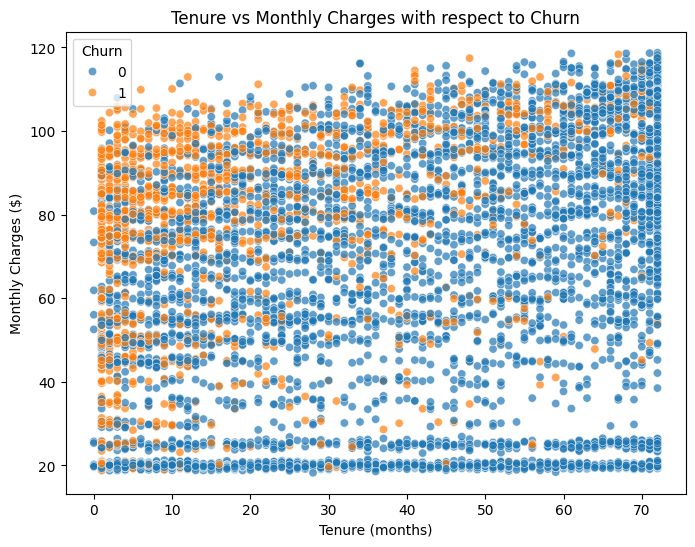

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.7)
plt.title('Tenure vs Monthly Charges with respect to Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.show()


The scatter plot suggests that customers with high monthly charges or low tenure are most likely to churn, while those with low monthly charges or high tenure tend to be loyal.

In [ ]:
df = df.drop(columns=['customerID', 'gender'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Label encoding for binary or ordinal columns
le = LabelEncoder()
label_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract',
              'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies']

for col in label_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encoding for nominal categorical columns
dummy_cols = ['MultipleLines', 'InternetService', 'PaymentMethod']

df = pd.get_dummies(df, columns=dummy_cols, drop_first=True, dtype=int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   OnlineSecurity                         7043 non-null   int64  
 6   OnlineBackup                           7043 non-null   int64  
 7   DeviceProtection                       7043 non-null   int64  
 8   TechSupport                            7043 non-null   int64  
 9   StreamingTV                            7043 non-null   int64  
 10  StreamingMovies                        7043 non-null   int64  
 11  Cont

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = df['TotalCharges'].astype(float)

df = df.dropna(subset=['TotalCharges'])


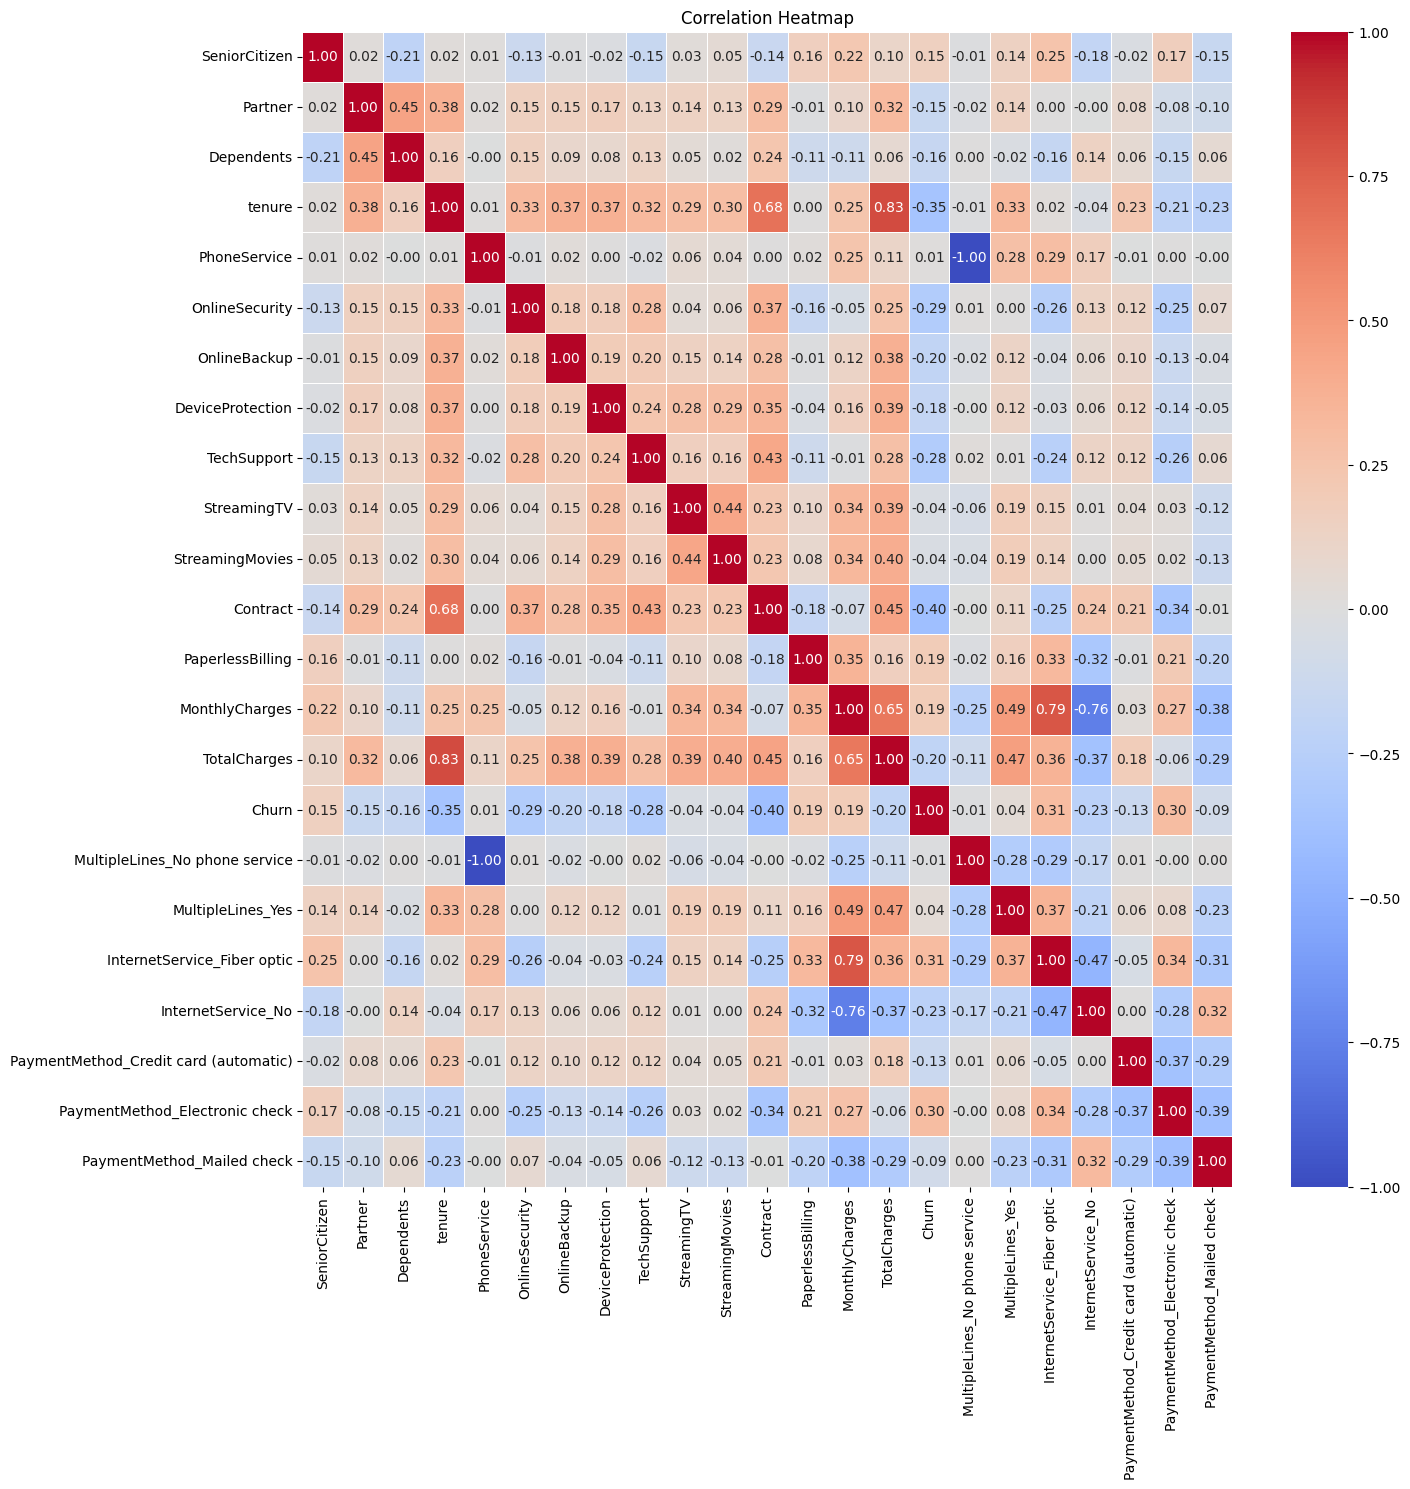

In [ ]:
corr = df.corr(numeric_only=True)


plt.figure(figsize=(15, 15))

# Create heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
df = df.drop(['TotalCharges',
              'MultipleLines_No phone service'], axis=1)

In [ ]:
pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Contract,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,2,0,0,0,...,0,1,29.85,0,0,0,0,0,1,0
1,0,0,0,34,1,2,0,2,0,0,...,1,0,56.95,0,0,0,0,0,0,1
2,0,0,0,2,1,2,2,0,0,0,...,0,1,53.85,1,0,0,0,0,0,1
3,0,0,0,45,0,2,0,2,2,0,...,1,0,42.30,0,0,0,0,0,0,0
4,0,0,0,2,1,0,0,0,0,0,...,0,1,70.70,1,0,1,0,0,1,0


In [ ]:
X=df.drop('Churn',axis=1)
X.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,2,0,0,0,0,0,1,29.85,0,0,0,0,1,0
1,0,0,0,34,1,2,0,2,0,0,0,1,0,56.95,0,0,0,0,0,1
2,0,0,0,2,1,2,2,0,0,0,0,0,1,53.85,0,0,0,0,0,1
3,0,0,0,45,0,2,0,2,2,0,0,1,0,42.30,0,0,0,0,0,0
4,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,0,0,1,0


In [ ]:
y=df['Churn']
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)   # increase max_iter to ensure convergence
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ Accuracy: 0.7910447761194029

📊 Confusion Matrix:
 [[917 116]
 [178 196]]


In [ ]:
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))


📋 Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
cls=RandomForestClassifier(n_estimators=600,criterion='entropy',random_state=0)

In [ ]:
cls.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=600, random_state=0)

In [ ]:
y_pred=cls.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
results = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(results)
print('Accuracy Score:', accuracy_score(y_test, y_pred))

Confusion Matrix:
[[914 119]
 [193 181]]
Accuracy Score: 0.7782515991471215


A brief Summary of all the models:

Logistic Regression:

Accuracy 79.8%,

RandomForest:

Accuracy 77.8%,
